In [1]:
import os
from transformers import AutoModel
import torch
from PIL import Image
from sqlalchemy import select
from meipi.indexing.db import pgEngine, DBPic, DBDinoV2Vector
from meipi.indexing import appconf
from meipi.indexing.embedding import generate_image_embeddings, create_image_batches

#DATA_DIR = "/home/padmin/Development/projekte/meipi-indexing/data/"


In [2]:
assert torch.cuda.is_available()
model_name = "facebook/dinov2-with-registers-large"
os.environ["PYTORCH_CUDA_ALLOC_CONF"]="expandable_segments:True"
torch.backends.cuda.matmul.allow_tf32 = True
model = AutoModel.from_pretrained(model_name)


In [3]:
dbengine = pgEngine(appconf.db_conn_string, enginekwargs={"echo":False})
dbengine.metadata.create_all(dbengine.engine)
with dbengine.get_session() as session:
    stmt = select(DBPic.id, DBPic.thumbarray).where(DBPic.thumbarray != None)
    pic_ids, images = zip(*session.execute(stmt).all())


In [4]:
inp_batches = create_image_batches(images, model_name, batch_size=100)

In [ ]:

embeddings = generate_image_embeddings(model, inp_batches, device="cuda")
vecs = list(zip(pic_ids, embeddings))

In [ ]:
%%script true
with dbengine.get_session() as session:
    for pic_id, vec in vecs:
        dino_vec = DBDinoV2Vector(pic_id=pic_id, vector=vec)
        session.add(dino_vec)
    session.flush()
    session.commit()

In [7]:
similarity = torch.nn.CosineSimilarity(dim=1)


In [8]:
def get_sindex(n):
    simlist = list(enumerate(similarity(torch.tensor(embeddings), torch.tensor(embeddings[n:n+1]))))
    return sorted(simlist, key=lambda s: s[1], reverse=True)

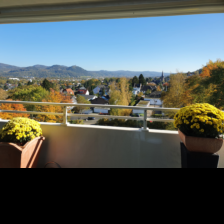

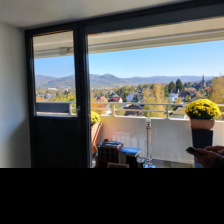

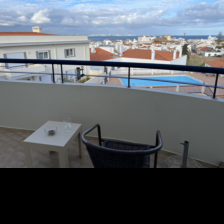

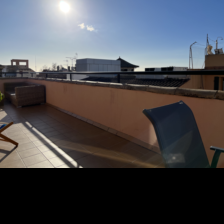

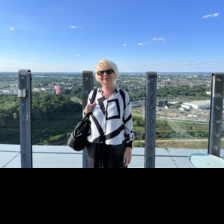

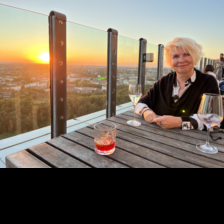

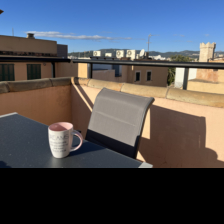

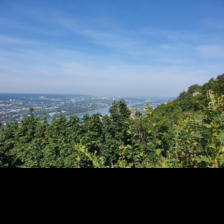

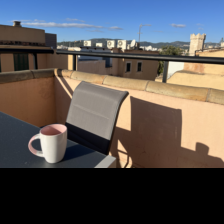

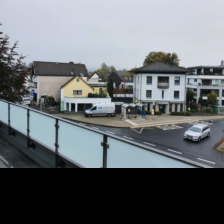

In [9]:
import random
num = random.randint(0, len(images)-1)
for i, sim in list(get_sindex(num))[:10]:
    display(Image.fromarray(images[i]))
    #print(f"Sim: {sim:.4f}, Label: {model.config.id2label[labels[i]]}")